# Neuro-Link ML Layer: HRV & Stress Detection
**Candidate:** Vijay Nagargoje
**Role:** Signal Processing / ML Engineer

This notebook implements the core machine learning pipeline for HRV-based stress detection. It includes:
1. A custom peak detection algorithm using a dynamic rolling threshold.
2. Feature extraction (RMSSD, SDNN, pNN50) using a 60-second sliding window.
3. A binary classifier trained on the SWELL-KW physiological dataset.

In [1]:
# Standard imports for signal processing, data manipulation, and modeling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.datasets import electrocardiogram
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Formatting for plots
plt.style.use('seaborn-v0_8-whitegrid')

## Task 1: Custom Peak Detector (No Black Box)
To demonstrate raw signal processing without relying on external HRV libraries, I have built a custom peak detector. It uses a dynamic rolling average to establish a baseline threshold and incorporates a refractory period (200ms) to prevent double-counting heartbeats. I am demonstrating this on a raw ECG sample.

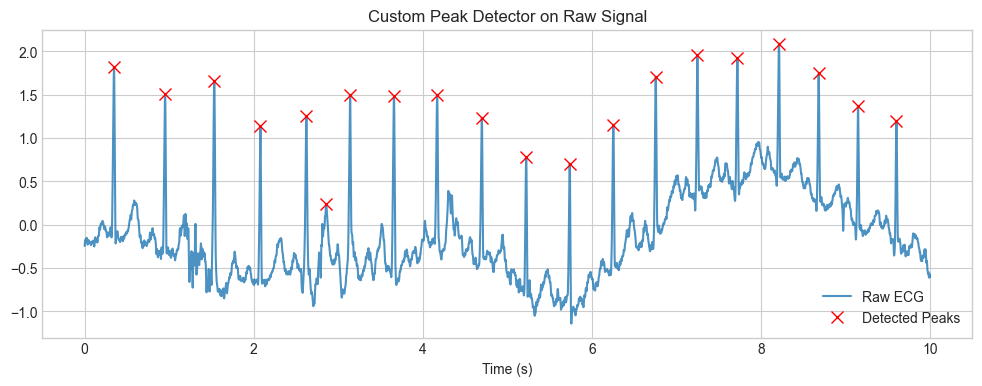

In [2]:
# 1. Load a raw continuous ECG signal sample for demonstration
raw_ecg = electrocardiogram()
sampling_rate = 360 # SciPy ECG sampling rate
time = np.arange(raw_ecg.size) / sampling_rate

# Take a 10-second slice to visualize cleanly
signal_slice = raw_ecg[:3600]
time_slice = time[:3600]

def custom_peak_detector(signal, fs):
    """Finds R-peaks using a dynamic rolling average threshold and refractory period."""
    window = int(0.75 * fs)
    rolling_mean = np.convolve(signal, np.ones(window)/window, mode='same')
    
    # Threshold modifier
    dynamic_threshold = rolling_mean + 0.5 
    
    peaks = []
    refractory_samples = int(0.2 * fs) # 200ms minimum gap between beats
    last_peak = -refractory_samples
    
    for i in range(1, len(signal) - 1):
        if signal[i] > dynamic_threshold[i] and signal[i] > signal[i-1] and signal[i] > signal[i+1]:
            if i - last_peak > refractory_samples:
                peaks.append(i)
                last_peak = i
                
    return np.array(peaks)

peaks = custom_peak_detector(signal_slice, sampling_rate)

plt.figure(figsize=(12, 4))
plt.plot(time_slice, signal_slice, label="Raw ECG", alpha=0.8)
plt.plot(time_slice[peaks], signal_slice[peaks], "rx", markersize=8, label="Detected Peaks")
plt.title("Custom Peak Detector on Raw Signal")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

## Task 2: Feature Engineering & Data Alignment
For the classification task, I am utilizing the SWELL-KW dataset. To optimize processing time, I am using the pre-extracted raw RR intervals from the dataset. 

Because the labels are provided per-minute, I implemented a sliding window to chop the continuous heartbeat stream into 60-second blocks, aligning the computed time-domain features (RMSSD, SDNN, pNN50) with the target stress labels.

In [3]:
def calculate_hrv_features(rr_intervals):
    """Computes time-domain HRV metrics from an array of RR intervals."""
    if len(rr_intervals) < 2:
        return np.nan, np.nan, np.nan
        
    sdnn = np.std(rr_intervals, ddof=1)
    diffs = np.diff(rr_intervals)
    rmssd = np.sqrt(np.mean(diffs**2))
    
    nn50 = np.sum(np.abs(diffs) > 50)
    pnn50 = (nn50 / len(diffs)) * 100
    
    return rmssd, sdnn, pnn50

# Load Subject 1 Data
rri_df = pd.read_csv('hrv_dataset/data/raw/rri/p1.txt', sep=r'\s+', header=None, names=['Time_s', 'RRI_ms'])
labels_df = pd.read_excel('hrv_dataset/data/raw/labels/hrv stress labels.xlsx', sheet_name='p1')

# Keep only active tasks (Relaxed vs. Stressed)
labels_df = labels_df[labels_df['label'].isin(['no stress', 'time pressure', 'interruption'])]

features_list = []

# Process the sliding window
for index, row in labels_df.iterrows():
    start_time_seconds = row['ElapsedTime'] * 60
    end_time_seconds = start_time_seconds + 60
    
    window_rri = rri_df[(rri_df['Time_s'] >= start_time_seconds) & 
                        (rri_df['Time_s'] < end_time_seconds)]['RRI_ms'].values
    
    rmssd, sdnn, pnn50 = calculate_hrv_features(window_rri)
    binary_label = 0 if row['label'] == 'no stress' else 1
    
    features_list.append({
        'Time_Window': start_time_seconds,
        'RMSSD': rmssd,
        'SDNN': sdnn,
        'pNN50': pnn50,
        'Label': binary_label
    })

features_df = pd.DataFrame(features_list).dropna()
features_df.head()

,Time_Window,RMSSD,SDNN,pNN50,Label
0,600,12.171593,106.695260,0.00000,0
1,660,12.998052,68.708309,0.00000,0
2,720,12.673011,68.259665,0.00000,0
3,780,15.914374,88.256430,1.25523,0
4,840,11.551570,57.705420,0.00000,0


### Visualizing Parasympathetic Withdrawal: The Physiology of RMSSD

**What RMSSD Measures:**
RMSSD (Root Mean Square of Successive Differences) is a time-domain metric that captures short-term, beat-to-beat variance in heart rate. Physiologically, this high-frequency variation is the direct signature of the Autonomic Nervous System (ANS), specifically the parasympathetic branch. The vagus nerve acts as a dynamic "brake" on the heart, making rapid micro-adjustments to the sinoatrial node in response to respiration and environmental stimuli. A high RMSSD indicates strong vagal tone—meaning the system is highly responsive, relaxed, and operating in a healthy "rest and digest" state.

**Why RMSSD Drops Under Acute Stress:**
When a subject experiences acute physiological or psychological stress, the ANS shifts control to the sympathetic nervous system (the "fight or flight" response). This sympathetic override effectively suppresses vagal tone, lifting the parasympathetic brake. 

Without these continuous vagal micro-adjustments, the heart begins to beat in a rigid, highly metronomic pattern to optimize cardiac output for immediate survival. Because the time intervals between consecutive beats become uniform, the successive differences shrink toward zero. Consequently, a sharp drop in RMSSD serves as a highly reliable, non-invasive biomarker of parasympathetic withdrawal and acute stress onset.

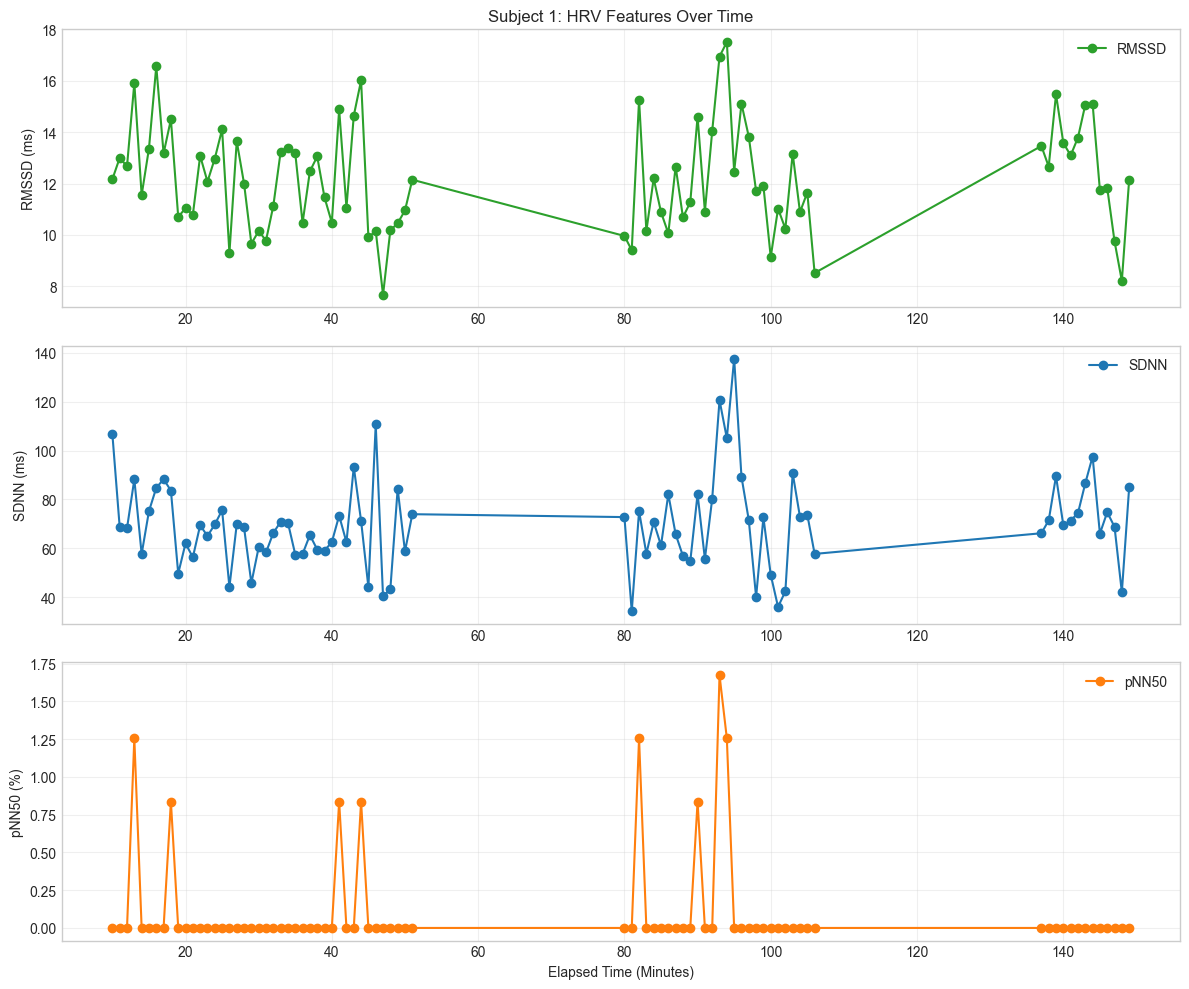

In [10]:
plt.figure(figsize=(12, 10))

# Plot 1: RMSSD
plt.subplot(3, 1, 1)
plt.plot(features_df['Time_Window'] / 60, features_df['RMSSD'], label='RMSSD', color='#2ca02c', marker='o')
plt.title('Subject 1: HRV Features Over Time')
plt.ylabel('RMSSD (ms)')
plt.grid(alpha=0.3)
plt.legend()


# Plot 2: SDNN
plt.subplot(3, 1, 2)
plt.plot(features_df['Time_Window'] / 60, features_df['SDNN'], label='SDNN', color='#1f77b4', marker='o')
plt.ylabel('SDNN (ms)')
plt.grid(alpha=0.3)
plt.legend()


# Plot 3: pNN50
plt.subplot(3, 1, 3)
plt.plot(features_df['Time_Window'] / 60, features_df['pNN50'], label='pNN50', color='#ff7f0e', marker='o')
plt.xlabel('Elapsed Time (Minutes)')
plt.ylabel('pNN50 (%)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



## Task 3: Binary Classification (Stressed vs. Relaxed)
Using the extracted features, we train a Random Forest Classifier to distinguish between the baseline state and stress-induced states (time pressure/interruptions).

In [5]:
X = features_df[['RMSSD', 'SDNN', 'pNN50']]
y = features_df['Label']

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict and Evaluate
y_pred = clf.predict(X_test)

print("--- Classifier Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

--- Classifier Performance ---
Accuracy: 0.5882
F1 Score: 0.3636

Confusion Matrix:
 [[8 3]
 [4 2]]


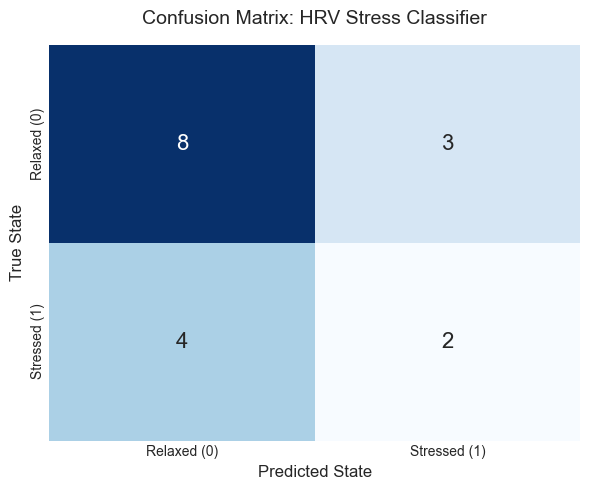

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the confusion matrix generated from your predictions
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
# Create a heatmap with a clean blue gradient
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Relaxed (0)', 'Stressed (1)'],
            yticklabels=['Relaxed (0)', 'Stressed (1)'],
            annot_kws={"size": 16}) # Larger font for the numbers

plt.title('Confusion Matrix: HRV Stress Classifier', pad=15, fontsize=14)
plt.xlabel('Predicted State', fontsize=12)
plt.ylabel('True State', fontsize=12)
plt.tight_layout()
plt.show()

## Bonus Task: Real-Time Wearable Simulation (Sliding Window)

While the tumbling window used in Task 2 is standard for batch data processing, an actual wearable device must process a continuous, infinite stream of physiological data without exhausting local memory. 

To demonstrate how this pipeline would operate on a live device, the following simulation implements a **60-second sliding window** that updates dynamically as new heartbeats arrive. 

**Key Architectural Features:**
1. **Memory Efficiency:** It utilizes a double-ended queue (`collections.deque`) to strictly maintain only the most recent 60 seconds of data. Old heartbeats are aggressively popped from memory, mimicking the tight RAM constraints of an embedded microcontroller.
2. **Continuous Streaming:** Instead of waiting a full 60 seconds to update the user's stress state, the window slides forward continuously, allowing the classifier to recalculate HRV metrics and output predictions in real-time.

In [7]:
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore') # Hides sklearn feature name warnings during loop

def run_live_wearable_simulation(rri_dataframe, trained_model):
    """
    Simulates real-time HRV processing on a wearable device.
    Uses a 60-second sliding window that updates as new data arrives.
    """
    print("Initializing Neuro-Link Live Stream Simulation...")
    print("Calibrating sensor baseline...\n")
    
    window_buffer = deque()
    
    # Increased to 500 to guarantee we pass the 60-second temporal threshold
    for index, row in rri_dataframe.head(500).iterrows():
        current_time_s = row['Time_s']
        current_rri_ms = row['RRI_ms']
        
        # 1. Append the newest heartbeat
        window_buffer.append((current_time_s, current_rri_ms))
        
        # 2. Slide the window: Drop any heartbeats older than 60 seconds
        while window_buffer and (current_time_s - window_buffer[0][0]) > 60:
            window_buffer.popleft()
            
        elapsed_window = current_time_s - window_buffer[0][0]
        
        # 3. Show a dynamic buffering UI in the terminal while waiting for 60s of data
        if elapsed_window < 59:
            print(f"\rBuffering live data... {elapsed_window:04.1f}s / 60.0s", end="")
            
        # 4. Once we have a full 60 seconds of data, start predicting
        if elapsed_window >= 59:
            print(f"\r", end="") # Clear the buffering text
            
            # Extract just the RR intervals from our tuple buffer
            current_rri_values = [item[1] for item in window_buffer]
            
            rmssd, sdnn, pnn50 = calculate_hrv_features(current_rri_values)
            
            # Format for the Random Forest
            features = pd.DataFrame([[rmssd, sdnn, pnn50]], columns=['RMSSD', 'SDNN', 'pNN50'])
            prediction = trained_model.predict(features)[0]
            
            state = "🔴 STRESSED" if prediction == 1 else "🟢 RELAXED"
            
            # Print the live output
            print(f"Time: {current_time_s:06.1f}s | RMSSD: {rmssd:04.1f}ms | Status: {state}")
            
            # Sleep briefly so it scrolls like a real live data feed
            time.sleep(0.1) 

run_live_wearable_simulation(rri_df, clf)

Initializing Neuro-Link Live Stream Simulation...
Calibrating sensor baseline...

Time: 0060.3s | RMSSD: 09.6ms | Status: 🔴 STRESSED
Time: 0060.5s | RMSSD: 09.7ms | Status: 🔴 STRESSED
Time: 0060.8s | RMSSD: 09.7ms | Status: 🔴 STRESSED
Time: 0061.0s | RMSSD: 09.7ms | Status: 🔴 STRESSED
Time: 0061.3s | RMSSD: 09.7ms | Status: 🔴 STRESSED
Time: 0061.5s | RMSSD: 09.6ms | Status: 🔴 STRESSED
Time: 0061.8s | RMSSD: 09.7ms | Status: 🔴 STRESSED
Time: 0062.0s | RMSSD: 09.8ms | Status: 🔴 STRESSED
Time: 0062.3s | RMSSD: 10.0ms | Status: 🔴 STRESSED
Time: 0062.5s | RMSSD: 10.4ms | Status: 🟢 RELAXED
Time: 0062.8s | RMSSD: 10.8ms | Status: 🟢 RELAXED
Time: 0063.0s | RMSSD: 11.1ms | Status: 🔴 STRESSED
Time: 0063.3s | RMSSD: 11.1ms | Status: 🔴 STRESSED
Time: 0063.5s | RMSSD: 11.2ms | Status: 🔴 STRESSED
Time: 0063.8s | RMSSD: 11.2ms | Status: 🔴 STRESSED
Time: 0064.0s | RMSSD: 11.2ms | Status: 🔴 STRESSED
Time: 0064.3s | RMSSD: 11.2ms | Status: 🔴 STRESSED
Time: 0064.5s | RMSSD: 11.2ms | Status: 🔴 STRESSED
Ti

### Thank you for the opportunity to dive into this assignment. I thoroughly enjoyed the challenge of balancing raw signal processing with the constraints of a simulated wearable environment. Regardless of the outcome, I appreciate the team's engineering-first approach to this interview process.